In [1]:
%pip install sentence-transformers

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


c:\Users\Mitali Kalburgi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# Step 1: Sentences (10 sentences, 3 topics)
sentences = [
    # Cricket
    "The bowler took three wickets in one over",
    "The batsman scored a century in the match",
    "The team won the cricket match by 5 runs",

     # Cooking
    "Add salt and spices while cooking the curry",
    "Boil the pasta until it becomes soft",
    "Chop vegetables finely before frying",

    # Cybersecurity
    "Use strong passwords to protect your accounts",
    "Cyber attacks can steal sensitive data",
    "Install antivirus software to stay safe",
    "Encryption helps secure online communication"
]

In [4]:
# Step 2: Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10287.01it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
# Step 3: Generate embeddings
embeddings = model.encode(sentences)

In [6]:
# Step 4: Cosine similarity matrix
similarity_matrix = cosine_similarity(embeddings, embeddings)

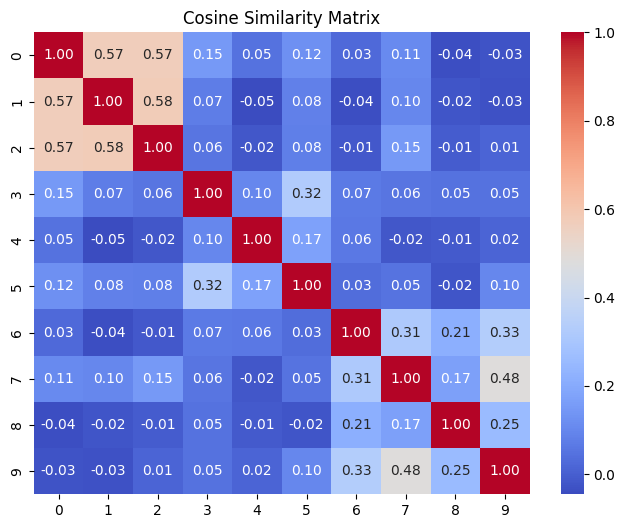

In [7]:
# Step 5: Display heatmap
plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Cosine Similarity Matrix")
plt.show()

In [8]:
# Step 6: Query
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query)

In [9]:
# Step 7: Compare with all sentences
similarities = cosine_similarity([query_embedding], embeddings)[0]

In [10]:
# Step 8: Get top 2 matches (excluding itself)
top_indices = np.argsort(similarities)[::-1]

In [11]:
print("\nTop similar sentences:")
count = 0
for idx in top_indices:
    if sentences[idx] != query:
        print(sentences[idx], "-> Score:", similarities[idx])
        count += 1
    if count == 2:
        break


Top similar sentences:
The team won the cricket match by 5 runs -> Score: 0.5704838
The batsman scored a century in the match -> Score: 0.5682195
